In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA


In [ ]:
class KMeansScratch:
    def __init__(self, n_clusters, max_iters=100, tol=1e-4):
        self.k = n_clusters
        self.max_iters = max_iters
        self.tol = tol

    def fit(self, X): # This method trains the K-Means model
        random_indices = np.random.choice(len(X), self.k, replace=False)#chooses random indices.
        self.centroids = X[random_indices] #

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.k)])
            shift = np.linalg.norm(self.centroids - new_centroids)
            if shift < self.tol:
                break
            self.centroids = new_centroids
        self.labels_ = labels

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign_clusters(X)

In [ ]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [ ]:
X_data=pd.DataFrame(cancer.data)
X_data.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X_data.columns=["f"+str(i) for i in range(len(X_data.columns))]
X_data.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
print(cancer.target_names)

['malignant' 'benign']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeansScratch(n_clusters=2, max_iters=100, tol=1e-4)
model.fit(X_scaled)


In [ ]:
if np.mean(model.labels_ == y) < 0.5:
    aligned_labels = 1 - model.labels_
else:
    aligned_labels = model.labels_

print("--- Evaluation Results ---")
print("Confusion Matrix:")
print(confusion_matrix(y, aligned_labels))
print("\nClassification Report:")
print(classification_report(y, aligned_labels, target_names=cancer.target_names))

--- Evaluation Results ---
Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.83      0.88       212
      benign       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



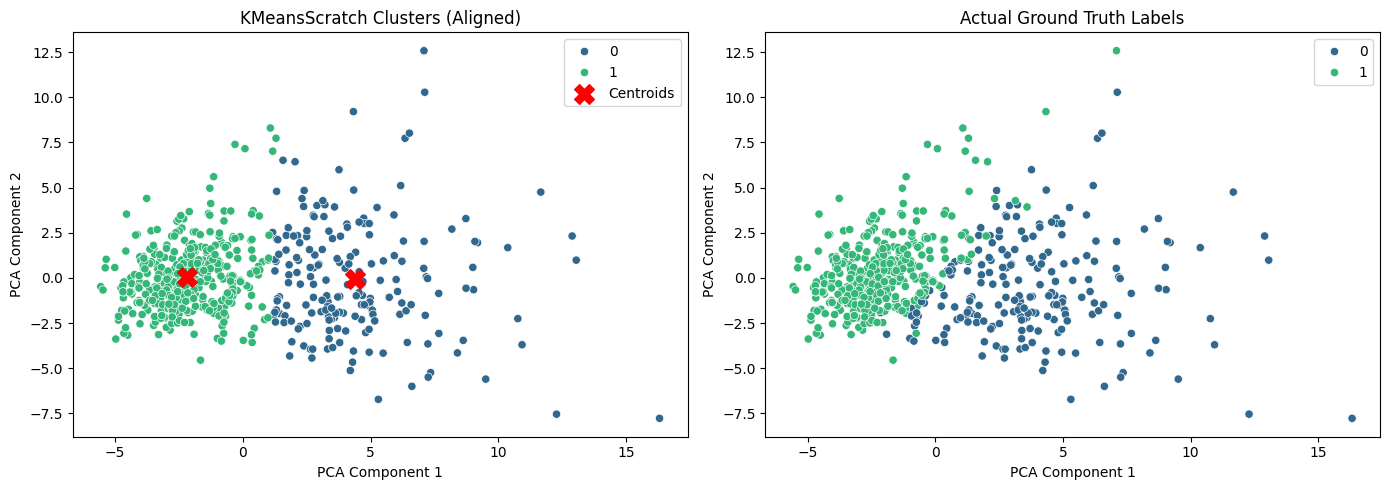

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model.centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Scratch K-Means Clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=aligned_labels, palette='viridis', ax=axes[0])
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
axes[0].set_title('KMeansScratch Clusters (Aligned)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()

# Plot Ground Truth
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', ax=axes[1])
axes[1].set_title('Actual Ground Truth Labels')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

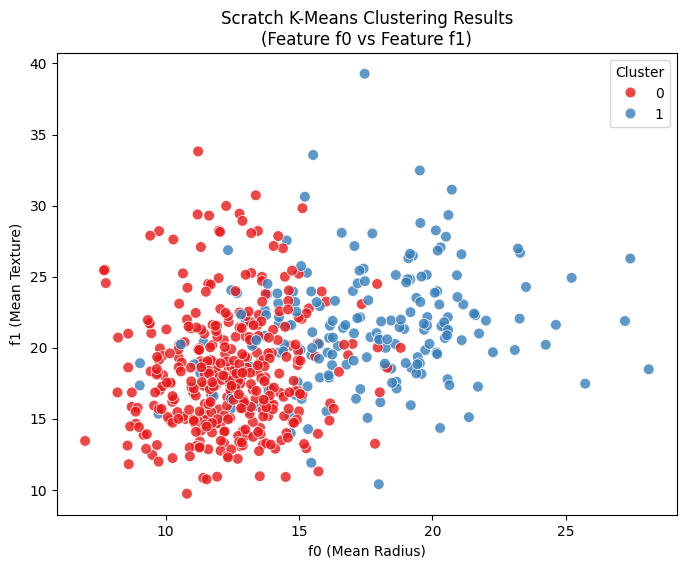

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# Set seed for reproducible cluster initialization
np.random.seed(42)

class KMeansScratch:
    def __init__(self, n_clusters, max_iters=100, tol=1e-4):
        self.k = n_clusters
        self.max_iters = max_iters
        self.tol = tol

    def fit(self, X): # This method trains the K-Means model
        random_indices = np.random.choice(len(X), self.k, replace=False) # chooses random indices.
        self.centroids = X[random_indices]

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)

            # Safe centroid update in case of empty cluster assignments
            new_centroids = np.zeros_like(self.centroids)
            for i in range(self.k):
                cluster_points = X[labels == i]
                if len(cluster_points) > 0:
                    new_centroids[i] = cluster_points.mean(axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            shift = np.linalg.norm(self.centroids - new_centroids)
            if shift < self.tol:
                break
            self.centroids = new_centroids
        self.labels_ = labels

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign_clusters(X)

# Load data
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Create DataFrame with custom column names (f0, f1, ..., f29)
X_data = pd.DataFrame(cancer.data)
X_data.columns = ["f" + str(i) for i in range(len(X_data.columns))]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit custom K-Means model
model = KMeansScratch(n_clusters=2, max_iters=100, tol=1e-4)
model.fit(X_scaled)

# Add predicted cluster labels to DataFrame for plotting
X_data['Cluster'] = model.labels_

# Plot two original features directly (f0: mean radius vs f1: mean texture)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=X_data,
    x='f0',
    y='f1',
    hue='Cluster',
    palette='Set1',
    s=60,
    alpha=0.8
)

plt.title("Scratch K-Means Clustering Results\n(Feature f0 vs Feature f1)")
plt.xlabel("f0 (Mean Radius)")
plt.ylabel("f1 (Mean Texture)")
plt.legend(title="Cluster")
plt.show()